In [ ]:
#ImageNet est un très grand base de données d'images annotées produit par ImageNet
#Les models entrainner sur la base de ImageNet
#VGG19
#ResNet50
#MobileNetV2


In [ ]:
#On va utilisé VGG16


In [3]:
#Install TensorFlow
!pip install tensorflow

In [3]:
#Importer les packages
import os #Manipuler les chemins des fichiers
import numpy as np
import tensorflow as tf
from glob import glob  #Extraire le nombre de fichiers


from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator #Permet d'augmenter le nombre de photos
from keras.layers import Dense,Flatten
from keras.models import Model


In [4]:
#Importer la base de données
data_path = r"C:\Users\j\Desktop\Orange - Copie\Computer vision\Pneumonie\PneumonieDataset\chest_xray"


In [5]:
#Chemin vers la base de donnée d'entrainement
train_dir=os.path.join(data_path,'train')
#Chemin vers la base de donnée de test                      
test_dir=os.path.join(data_path,'test')

In [ ]:
#Preparer le model de base

In [6]:
#Specification de la taille des images
#Pour le CNN ce sera tridimentionel le width,le height et le RGB
IMG_SHAPE=(224,224,3)
#Creation du model dejà entrainer donc VGG16
#input_shape:la taille des données d'entrées
#include_top :Ajouter la couche de sortie
#weights: les poids
base_model=VGG16(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Bloquer le model de base
base_model.trainable=False

In [8]:
base_model.output
#Chaque image du batch est désormais réduite à une carte de caractéristiques de 7×7 pixels,

#Et chaque pixel contient 512 valeurs de profondeur (un vecteur de caractéristiques).

<KerasTensor shape=(None, 7, 7, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>

In [9]:
#Ajouter les couches de sorties
x=Flatten()(base_model.output)
prediction=Dense(2,activation='softmax')(x)


In [10]:
#Création du modèle global
model=Model(inputs=base_model.input,outputs=prediction)
model.summary() 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │          50,178 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [12]:
#Creer les photos augmentés
train_datagen=ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)
trainning_set=train_datagen.flow_from_directory(train_dir,target_size=(224,224),batch_size=32,class_mode='categorical')
test_set=test_datagen.flow_from_directory(test_dir,target_size=(224,224),batch_size=32,class_mode='categorical')
class_indices = trainning_set.class_indices

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [30]:
import os
print(os.path.exists(train_dir))  # Doit afficher True


True


In [33]:
#Appliquer le model
model.fit(trainning_set,epochs=2,validation_data=test_set)

C:\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 1558s 10s/step - accuracy: 0.9214 - loss: 0.2023 - val_accuracy: 0.9199 - val_loss: 0.2392
Epoch 2/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 1428s 9s/step - accuracy: 0.9574 - loss: 0.1159 - val_accuracy: 0.9215 - val_loss: 0.2251


In [34]:
valid_loss,valid_accuracy=model.evaluate(test_set)

20/20 ━━━━━━━━━━━━━━━━━━━━ 177s 9s/step - accuracy: 0.9215 - loss: 0.2251


In [35]:
print("Accuracy after transfer learning: {} ".format(valid_accuracy))

Accuracy after transfer learning: 0.9214743375778198 


In [37]:
# Sauvegarder le modèle
    
model.save('mon_classificateur.h5')
print("\nModèle sauvegardé: mon_classificateur.h5")


Modèle sauvegardé: mon_classificateur.h5


In [1]:
#Validation du model
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class ClassificateurPersonnalise:
    """Classificateur utilisant un modèle Keras sauvegardé"""

    def __init__(self, model_path, class_indices):
        # Charger le modèle entraîné sauvegardé (.h5 par exemple)
        self.model = load_model(model_path)

        # Inverser le dictionnaire {nom_classe: indice} -> {indice: nom_classe}
        # Cela facilite la récupération du nom de la classe à partir de la prédiction (argmax)
        self.classes = {v: k for k, v in class_indices.items()}

    def predire(self, image_path):
        """Charge une image, la prétraite, et renvoie la prédiction"""
        
        # Charger l'image disque et la redimensionner au format du modèle (224x224)
        img = image.load_img(image_path, target_size=(224, 224))
        
        # Convertir l'image en tableau numpy
        img_array = image.img_to_array(img)
        
        # Ajouter une dimension batch pour devenir (1,224,224,3)
        img_array = np.expand_dims(img_array, axis=0)
        
        # Normaliser les pixels entre 0 et 1
        img_array = img_array / 255.0
        
        # Obtenir les prédictions du modèle
        predictions = self.model.predict(img_array, verbose=0)
        
        # Récupérer l'indice de la classe la plus probable
        class_idx = np.argmax(predictions[0])
        
        # Récupérer la confiance associée
        confidence = predictions[0][class_idx]
        
        # Convertir en nom de classe à partir du dict inversé
        class_name = self.classes[class_idx]
        
        return class_name, confidence, predictions[0]

    def predire_et_afficher(self, image_path):
        """Affiche l'image, les probabilités, et renvoie la prédiction"""
        
        # Prédire l'image
        class_name, confidence, all_probs = self.predire(image_path)

        # Préparer la figure avec 2 colonnes : image + histogramme
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Charger l'image originale pour affichage
        img = image.load_img(image_path)
        axes[0].imshow(img)
        axes[0].set_title(f'Prédiction: {class_name}\nConfiance: {confidence*100:.1f}%')
        axes[0].axis('off')

        # Créer la liste des noms de classes dans l'ordre des indices
        class_names = [self.classes[i] for i in range(len(all_probs))]
        probs = all_probs * 100  # Conversion en %

        # Colorer en vert la classe prédite, bleu pour les autres
        colors = ['green' if i == np.argmax(all_probs) else 'skyblue'
                  for i in range(len(probs))]

        # Tracer les barres horizontales
        axes[1].barh(class_names, probs, color=colors)
        axes[1].set_xlabel('Probabilité (%)')
        axes[1].set_title('Confiance par classe')

        # Ajouter le texte avec les valeurs %
        for i, (name, prob) in enumerate(zip(class_names, probs)):
            axes[1].text(prob + 1, i, f'{prob:.1f}%', va='center')

        plt.tight_layout()
        plt.show()

        # Affichage
        print(f"\n=== RÉSULTAT ===")
        print(f"Classe prédite: {class_name}")
        print(f"Confiance: {confidence*100:.2f}%")

        return class_name, confidence

C:\Python311\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.4)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


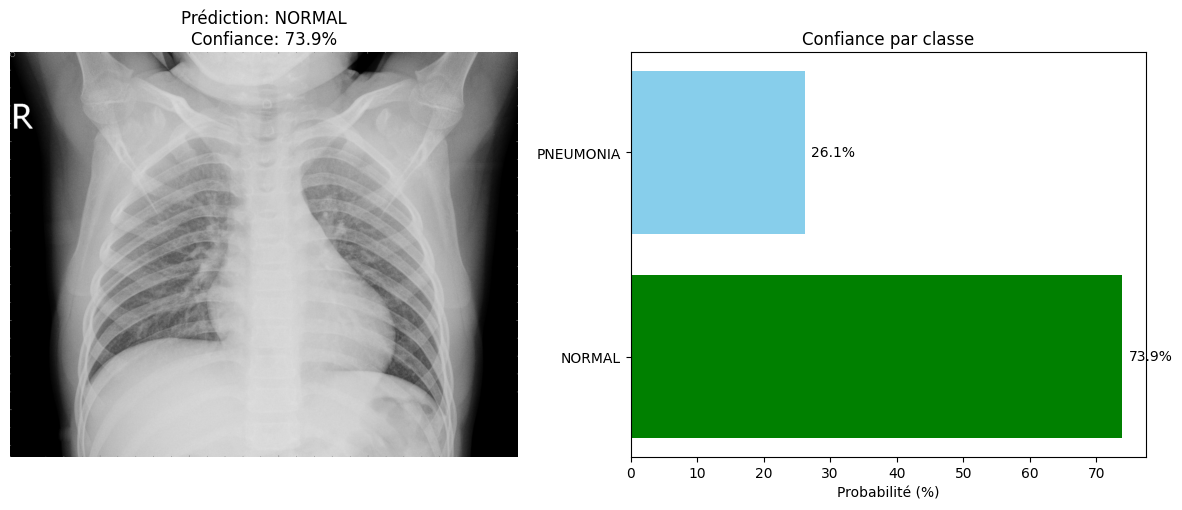


=== RÉSULTAT ===
Classe prédite: NORMAL
Confiance: 73.86%


In [17]:
# Utilisation
classificateur = ClassificateurPersonnalise('mon_classificateur.h5', class_indices)
classe, conf = classificateur.predire_et_afficher(
    r"C:\Users\j\Desktop\Orange - Copie\Computer vision\Pneumonie\PneumonieDataset\chest_xray\val\NORMAL\normal.jpeg"
)


In [14]:
class_indices = trainning_set.class_indices
print("Indices de classes :", class_indices)


Indices de classes : {'NORMAL': 0, 'PNEUMONIA': 1}


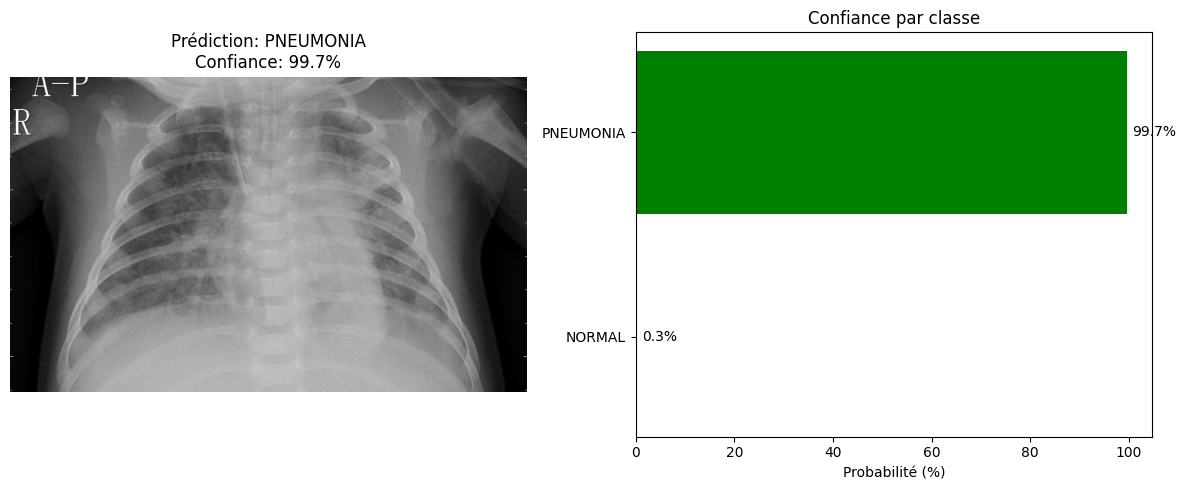


=== RÉSULTAT ===
Classe prédite: PNEUMONIA
Confiance: 99.72%


In [18]:
# Utilisation
classificateur = ClassificateurPersonnalise('mon_classificateur.h5', class_indices)
classe, conf = classificateur.predire_et_afficher(
    r"C:\Users\j\Desktop\Orange - Copie\Computer vision\Pneumonie\PneumonieDataset\chest_xray\val\PNEUMONIA\malade.jpeg"
)
